In [1]:
import sys,os
import numpy as np
import pydicom as dcm
import matplotlib.pyplot as plt

## Using functions from longiDICOM

In [2]:
# loading functions from modules (from another location, might need to do ../longiDICOM/code, or something
sys.path.append('../code')
from rs_tools import find_RS_file, find_ROI_names, get_all_ROI_contours, get_avg_ROI_z_and_slice, get_ROI_pixel_array

# Basic DICOM Loading

In [3]:
path_to_ct = '/mnt/iDriveShare/Kayla/CBCT_images/kayla_extracted/1288/20200916_CT_11_SEP_2020/' # Path to all CT, RD, RS, etc...

## Image Slices

In [4]:
# Load CT:
slices = [dcm.read_file(path_to_ct+ s) for s in os.listdir(path_to_ct) if 'CT' in s] # Assumes each CT file starts with 'CT', adjust accordingly
slices.sort(key = lambda x: (x.InstanceNumber)) # Sort by the instance number in the DICOM tag 
# Note: the isntance number should be in the correct slice order (1,2...N). 
#If it is not, you will need to sort based on the 'z' value in the ImagePositionPatient tag

# Image Sacping Parameters
CT_origin = slices[0].ImagePositionPatient
pixel_spacing = slices[0].PixelSpacing
CT_spacing = [pixel_spacing[0],pixel_spacing[1],slices[0].SliceThickness]

Displaying slice 60 out of 127


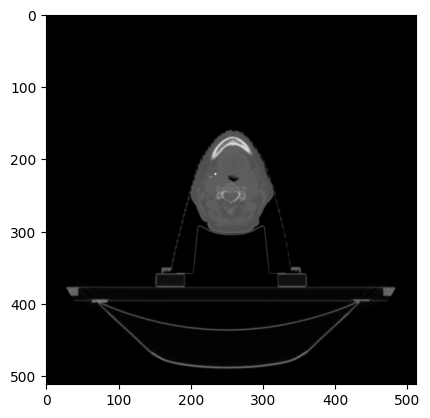

In [5]:
# View an image slice
slice_num = 60

plt.imshow(slices[slice_num].pixel_array, cmap='gray') # Here, it is slice 60. 

print("Displaying slice", slice_num, "out of", len(slices))

In [6]:
# ADD 3 VIEWS

## DICOM RT DOSE
### See "./Sample Notebook - RT Dose.ipynb" 

## DICOM RT PLAN

In [7]:
RP_file = os.path.join(path_to_ct,[x for x in os.listdir(path_to_ct) if 'RP' in x][0]) # file path to RP file

RP = dcm.read_file(RP_file) # Read file

In [8]:
# print(RP) #uncomment to print entire file

In [9]:
# everything is text based and needs to be accessed via nested tags
# Note for VMAT, there are many control points along the arc path, showing snapshots of the movement 



In [10]:
# Example: Basic Plan information
fx_data = RP.FractionGroupSequence[0] 
print("Num. Planned fractions:",fx_data.NumberOfFractionsPlanned)
print("Num. Beams:",fx_data.NumberOfBeams)

Num. Planned fractions: 21
Num. Beams: 7


In [11]:
# Note some beams maybe imaging beams (not treatment)
#e.g.:
print("Beam names")
for beam in RP.BeamSequence: # cycle through each beam
    print("Beam #",beam.BeamNumber, ":",beam.BeamName )


# CBCT, ANT Setup, RT LAT Setup, and LT LAT Setup are all imaging fields

print("_________________________________")
# You can also check if a dose was given by the beam, if none, it is not a treatment beam
for beam_ref in RP.FractionGroupSequence[0].ReferencedBeamSequence:
    print("Beam Number:", beam_ref.ReferencedBeamNumber)
    try:
        beam_dose = beam_ref.BeamDose
        print("         Dose given by this beam:",beam_dose)
    except:
        print("         No dose (not a treatment field)")

# Notice beams are cross referenced in various parts of the dicom tags with their number

Beam names
Beam # 1 : M1-1.1ARC1
Beam # 2 : M1-1.2ARC2
Beam # 3 : M1-1.3ARC3
Beam # 5 : CBCT
Beam # 6 : ANT Setup
Beam # 7 : RT LAT Setup
Beam # 4 : LT LAT Setup
_________________________________
Beam Number: 1
         Dose given by this beam: 0.82951478911742
Beam Number: 2
         Dose given by this beam: 0.66665554094528
Beam Number: 3
         Dose given by this beam: 0.50382966993731
Beam Number: 5
         No dose (not a treatment field)
Beam Number: 6
         No dose (not a treatment field)
Beam Number: 7
         No dose (not a treatment field)
Beam Number: 4
         No dose (not a treatment field)


In [12]:
# Example Gantry angle 
# For first beam (arc) 
for beam in RP.BeamSequence:
    print("--------------------------------------")
    print("Beam Number:", beam.BeamNumber)
    print("Delivery type:", beam.TreatmentDeliveryType) # here you can also see fi the type is TREATMENT or SETUP (imaging)
    beam_type = beam.BeamType
    print("Beam Type:", beam_type) #Static = one angle (simpler), dynamic = moving arc (many control points)
    print("Control points:", beam.NumberOfControlPoints)
    
    control_pts = beam.ControlPointSequence
    print("Start Angle:", control_pts[0].GantryAngle)
    if beam_type == 'DYNAMIC':
        print("Stop Angle:", control_pts[-1].GantryAngle)
        print("Direction:",control_pts[0].GantryRotationDirection  )

--------------------------------------
Beam Number: 1
Delivery type: TREATMENT
Beam Type: DYNAMIC
Control points: 114
Start Angle: 181
Stop Angle: 15
Direction: CW
--------------------------------------
Beam Number: 2
Delivery type: TREATMENT
Beam Type: DYNAMIC
Control points: 114
Start Angle: 15
Stop Angle: 181
Direction: CC
--------------------------------------
Beam Number: 3
Delivery type: TREATMENT
Beam Type: DYNAMIC
Control points: 114
Start Angle: 181
Stop Angle: 15
Direction: CW
--------------------------------------
Beam Number: 5
Delivery type: SETUP
Beam Type: STATIC
Control points: 2
Start Angle: 0
--------------------------------------
Beam Number: 6
Delivery type: SETUP
Beam Type: STATIC
Control points: 2
Start Angle: 0
--------------------------------------
Beam Number: 7
Delivery type: SETUP
Beam Type: STATIC
Control points: 2
Start Angle: 270
--------------------------------------
Beam Number: 4
Delivery type: SETUP
Beam Type: STATIC
Control points: 2
Start Angle: 90


## DICOM RT - STRUCTURE SET
### Note: Structure Sets are stored in x,y,z coordinates and need to be converted to pixel coordinates to be visualized on an image

In [22]:
# Using RS and CT loaded from before
RS = dcm.read_file(os.path.join(path_to_ct,find_RS_file(path_to_ct)))

# Check which names are available in the RT Struct given a keyword
names = find_ROI_names(RS, 'lung')
print("Structure names with keyword 'lung':",names)

# Body contour
names = find_ROI_names(RS, 'body')
print("Structure names with keyword 'body':",names)

# Find all names
print("\nAll structures:", find_ROI_names(RS)) # no keyword

Structure names with keyword 'lung': ['Lung~_L', 'Lung~_R']
Structure names with keyword 'body': ['BODY']

All structures: ['Cochlea_L', 'Cavity_Oral-PTV', 'Cavity_Oral', 'BODY', 'M1_CTV_6000', 'M1_CTV_6600', 'M1_PTV!_6000-05', 'M1_PTV_6600-05', 'Carina', 'Brainstem_PRV05', 'Brainstem', 'Brain', 'BrachialPlex_R', 'BrachialPlex_L', 'Bones^RadCalc', 'Bone_Mandible', 'Cochlea_R', 'CTV_6000', 'CTV_6600', 'Esophagus_S', 'Esophagus~^2cm', 'Eye_L', 'Eye_R', 'Glnd_Submand_L', 'Glnd_Thyroid', 'Larynx', 'Lens_L', 'Lens_R', 'Lips', 'Lobe_Temporal_L', 'Lobe_Temporal_R', 'Lung~_L', 'Lung~_R', 'Musc_Constrict_I', 'Musc_Constrict_M', 'Musc_Constrict_S', 'OpticChiasm', 'OpticNrv_L', 'OpticNrv_R', 'Parotid_L', 'Parotid_R', 'Pharynx', 'Pituitary', 'PTV!_6000-05', 'PTV_6600-05', 'Spc_Retrophar_L', 'Spc_Retrophar_R', 'SpinalCord~', 'SpinalCord~_PRV5', 'zDensityOverride', 'Skin']


#### Plotting contours on image

In [14]:
# Get contour x y z cords
dict_contours, z_lists = get_all_ROI_contours(['Lung~_L'], RS) # use correct name as found before

# finds middle slice of contour 'roi_slice' (you can use whichever 'slice_num' you want, this just helps find wehre it is to easily visualize
roi_slice, z_avg = get_avg_ROI_z_and_slice(z_lists) 
slice_num = int((z_avg-CT_origin[2])/CT_spacing[2])

# Get converted coords for plotting
roi_x, roi_y= get_ROI_pixel_array(dict_contours['Lung~_L'][roi_slice],CT_origin[0],CT_origin[1],pixel_spacing)


# Repeatig for body on same slice
dict_contours_body, z_lists = get_all_ROI_contours(['BODY'], RS) # use correct name as found before
roi_x_body, roi_y_body= get_ROI_pixel_array(dict_contours_body['BODY'][slice_num],CT_origin[0],CT_origin[1],pixel_spacing)


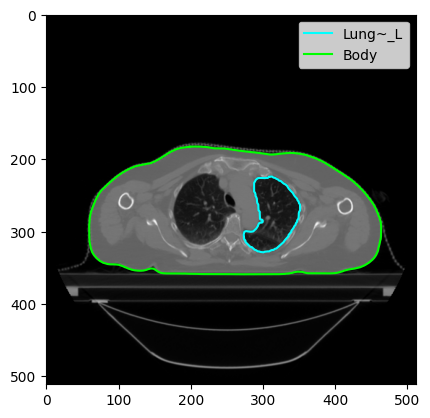

In [15]:
plt.imshow(slices[slice_num].pixel_array,cmap='gray')
plt.plot(roi_x,roi_y,'-',color='cyan',label='Lung~_L')
plt.plot(roi_x_body,roi_y_body,'-',color='lime',label='Body')
plt.legend()

### Visualize in 3D 
Note: This is a quick triangulation I made for visualization in Opal, converted to Python. It does not always work perfectly and can be improved. I found existing algorithms were too slow/did not work well.

In [16]:
# main functions in ../code/visualization3D.py if you need to modify
from visualization3D import get_contour_stack, render_body, plot_RS_structure

In [17]:
dict_contours_body, z_lists = get_all_ROI_contours(['BODY'], RS) # use correct name as found before
full_stack_int, keys = get_contour_stack('BODY', dict_contours_body,-100) # note you can use whichever structure name
pts, indices = render_body(full_stack_int,keys)

Contours containing the keyword BODY : ['BODY']
Rendering BODY contour...


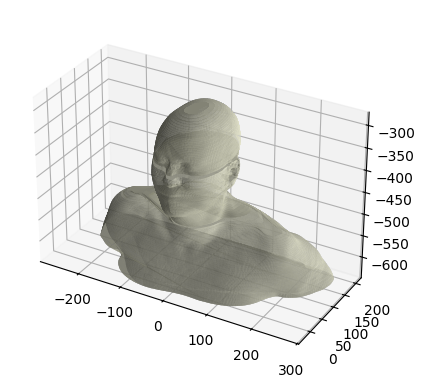

In [18]:
# RS = RS read file 
plot_RS_structure(RS,'BODY',z_cutoff=-1000,colour='beige')

Contours containing the keyword SpinalCord~ : ['SpinalCord~', 'SpinalCord~_PRV5']
Rendering SpinalCord~ contour...


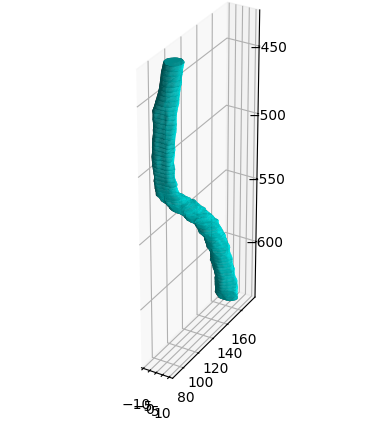

In [28]:
plot_RS_structure(RS,'SpinalCord~',z_cutoff=-1000,colour='cyan')